# CLM long spinup equilibrium checks - only over LCC-slected cells

This notebook reads annual mean `clm2.h0` files and checks 20-year rolling means of carbon, nitrogen, and water variables. `TSOI` and `H2OSOI` are taken from the soil level closest to 1 m; the selected depth is printed.

**Focus on** fast ajustable variables ('TWS', 'H2OSOI', 'TSOI'), while vegetation carbon is not the main variable we want stabilised.

*The yearly change in the 20-year rolling mean measures the difference between annual values 20 years apart, divided by 20. Persistently small changes in H2OSOI and TSOI near 1 m suggest that these variables are adjusting slowly in the LCC-modified cells. Check their changes in individual cells as well as the regional mean, since opposing local trends can cancel. TWS is unavailable, so this does not establish equilibrium of total water storage. Confirm that the FUT history files used the intended future CPLHIST forcing.*

👉 **Conclusion**: soil temperature and soil water near 1 m show little late-run drift in both the PD and future spinups, suggesting these local physical states have largely adjusted. Total water storage was not saved, and vegetation carbon is still changing, so the notebook does not establish full land-system equilibrium.

*How to use it*: \
Run on Betzy in `lcc-env`. Set `CASE_DIRS` to the archived land cases and confirm `BASE_SURFDATA` is the source surface file for the LCC modification. 

In [1]:
from pathlib import Path
import warnings
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

ARCHIVE = Path('/cluster/home/adelez/work/archive')#/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN_archive')
CASE_DIRS = {
    'PD CLIMATE': ARCHIVE / 'I2000Clm50BgcCropCplHist_f19_f19-20260925',
    'FUT CLIMATE': ARCHIVE / 'I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924',
}
VARIABLES = ['GPP', 'TOTVEGC', 'TOTVEGN', 'TWS', 'H2OSOI', 'TSOI', 'TOTSOMC', 'TOTECOSYSC', 'NPP', 'AR', 'HR', 'NEE', 'TLAI', 'TSA', 'H2OSNO', 'FSH', 'EFLX_LH_TOT']
CORE_VARIABLES = ['GPP', 'TOTVEGC', 'TOTVEGN', 'TWS', 'H2OSOI', 'TSOI']
SOIL_VARIABLES = {'H2OSOI', 'TSOI'}
SOIL_DEPTH_M = 1.0
ROLL_YEARS = 20
REGIONS = ('changed LCC cells',)

# Use the original CLM surface file from which the LCC surface was derived.
# If the control case did not use that exact file, set BASE_SURFDATA explicitly.
BASE_SURFDATA = Path('/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc')
BASE_CASE_LND_IN = Path('~/cases/BRL_FRST_XPSN/BRL_FRST_XPSN_archive/NF2100ssp585norbc_tropstratchem_spinup_f19_f19-3/CaseDocs/lnd_in').expanduser()
LCC_SURFDATA = Path('/cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc')
PFT_TOLERANCE_PP = 1e-6

BLOCK = 10
TREND_YEARS = 30

def files_in(case):
    roots = [case, case / 'lnd/hist', case / 'run']
    return sorted({p.resolve() for root in roots if root.is_dir() for p in root.glob('*.clm2.h0.*.nc')})

for name, case in CASE_DIRS.items():
    files = files_in(case)
    print(f'{name}: {len(files)} h0 files in {case}')
    if files:
        print('  first:', files[0].name, 'last:', files[-1].name)
    xml = case / 'env_run.xml'
    if xml.exists():
        root = ET.parse(xml).getroot()
        for key in ('DATM_CPLHIST_CASE', 'DATM_CPLHIST_DIR', 'DATM_CPLHIST_YR_START', 'DATM_CPLHIST_YR_END', 'STOP_N', 'RESUBMIT'):
            item = root.find(f'.//*[@id="{key}"]')
            if item is not None:
                print(f'  {key} = {item.get("value")}')


PD CLIMATE: 11 h0 files in /cluster/home/adelez/work/archive/I2000Clm50BgcCropCplHist_f19_f19-20260925
  first: I2000Clm50BgcCropCplHist_f19_f19-20260925.clm2.h0.0001-01-01-00000.nc last: I2000Clm50BgcCropCplHist_f19_f19-20260925.clm2.h0.0101-01-01-00000.nc
FUT CLIMATE: 11 h0 files in /cluster/home/adelez/work/archive/I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924
  first: I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924.clm2.h0.0001-01-01-00000.nc last: I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924.clm2.h0.0101-01-01-00000.nc


## Identify the changed land cells

Compare `PCT_NAT_PFT` in the original and LCC surface datasets. Set `BASE_SURFDATA` explicitly if the future control's `fsurdat` is not the exact source from which the LCC dataset was made. The mask includes any grid cell whose natural PFT percentages differ by more than `PFT_TOLERANCE_PP`; it does not include neighboring cells that may respond through coupled feedbacks. Coordinates are checked before applying the mask to CLM history output.

In [2]:
import re

def baseline_path():
    if BASE_SURFDATA is not None:
        return Path(BASE_SURFDATA).expanduser()
    if not BASE_CASE_LND_IN.is_file():
        raise FileNotFoundError(f'Set BASE_SURFDATA to the original surface file; missing {BASE_CASE_LND_IN}')
    match = re.search(r"^\s*fsurdat\s*=\s*['\"]([^'\"]+)['\"]", BASE_CASE_LND_IN.read_text(), re.M)
    if not match:
        raise ValueError(f'No fsurdat found in {BASE_CASE_LND_IN}; set BASE_SURFDATA explicitly')
    return Path(match.group(1))

def load_changed_cells():
    baseline = baseline_path()
    if not baseline.is_file() or not LCC_SURFDATA.is_file():
        raise FileNotFoundError(f'Surface files missing: {baseline}, {LCC_SURFDATA}')
    with xr.open_dataset(baseline) as original, xr.open_dataset(LCC_SURFDATA) as lcc:
        a, b = original.PCT_NAT_PFT, lcc.PCT_NAT_PFT
        if a.dims != b.dims or a.shape != b.shape or 'natpft' not in a.dims:
            raise ValueError('PCT_NAT_PFT grid/PFT dimensions differ between surface files')
        if 'natpft' in a.coords and 'natpft' in b.coords and not np.array_equal(a.natpft.values, b.natpft.values):
            raise ValueError('Natural PFT indices differ between surface files')
        difference = np.abs(a.values - b.values)
        if np.any(np.isfinite(a.values) != np.isfinite(b.values)):
            raise ValueError('PCT_NAT_PFT missing-value masks differ')
        changed = np.any(difference > PFT_TOLERANCE_PP, axis=a.dims.index('natpft'))
        lat = np.asarray(lcc.LATIXY.values)
        lon = np.asarray(lcc.LONGXY.values) % 360
        if changed.shape != lat.shape or changed.shape != lon.shape:
            raise ValueError('Surface PFT and LATIXY/LONGXY grids differ')
        if not np.allclose(original.LATIXY.values, lat) or not np.allclose(original.LONGXY.values % 360, lon):
            raise ValueError('Baseline and LCC surface coordinates differ')
    print(f'Baseline: {baseline}')
    print(f'LCC surface: {LCC_SURFDATA}')
    print(f'Changed cells: {changed.sum()} of {changed.size} (tolerance {PFT_TOLERANCE_PP:g} percentage points)')
    if changed.any():
        print(f'Changed-cell latitude range: {lat[changed].min():.2f} to {lat[changed].max():.2f}°')
    else:
        raise ValueError('No changed PFT cells found; check that the baseline is the unmodified surface file')
    return changed, lat, lon

CHANGED_CELLS, SURFACE_LAT, SURFACE_LON = load_changed_cells()

def changed_mask_for(ds, weights):
    if CHANGED_CELLS.shape != weights.shape:
        raise ValueError(f'Surface mask {CHANGED_CELLS.shape} and history grid {weights.shape} differ')
    if ds.lat.ndim != 1 or ds.lon.ndim != 1:
        raise ValueError('Expected 1D history lat/lon coordinates; inspect this grid before masking')
    hist_lat, hist_lon = np.meshgrid(ds.lat.values, ds.lon.values % 360, indexing='ij')
    if not np.allclose(hist_lat, SURFACE_LAT, atol=1e-4) or not np.allclose(hist_lon, SURFACE_LON, atol=1e-4):
        raise ValueError('History coordinates do not match the surface grid; do not apply the mask by index')
    return xr.DataArray(CHANGED_CELLS, dims=weights.dims, coords=weights.coords)


Baseline: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc
LCC surface: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc
Changed cells: 1161 of 13824 (tolerance 1e-06 percentage points)
Changed-cell latitude range: 46.42 to 82.42°


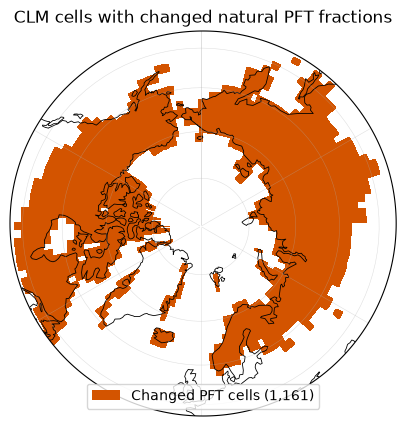

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.path import Path

# Sort longitudes into −180° to 180° for a continuous map.
lon = ((SURFACE_LON[0, :] + 180) % 360) - 180
order = np.argsort(lon)
lat = SURFACE_LAT[:, 0]
changed = CHANGED_CELLS[:, order]

if not np.allclose(SURFACE_LAT, lat[:, None]):
    raise ValueError("Surface latitude is not a regular 1D grid")
if not np.allclose(SURFACE_LON[:, order], SURFACE_LON[0, order]):
    raise ValueError("Surface longitude is not a regular 1D grid")

highlight = np.ma.masked_where(~changed, np.ones(changed.shape))

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": ccrs.Orthographic(0, 90)})
ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
ax.pcolormesh(
    lon[order], lat, highlight,
    transform=ccrs.PlateCarree(),
    shading="nearest",
    cmap=ListedColormap(["#D35400"]),
    vmin=0.5, vmax=1.5,
)
ax.coastlines(resolution="110m", linewidth=0.6)
ax.gridlines(linewidth=0.4, alpha=0.4)

theta = np.linspace(0, 2 * np.pi, 361)
circle = Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)
ax.set_boundary(circle, transform=ax.transAxes)

ax.legend(
    handles=[Patch(facecolor="#D35400", label=f"Changed PFT cells ({changed.sum():,})")],
    loc="lower center",
)
ax.set_title("CLM cells with changed natural PFT fractions")
plt.show()

## Annual means

Use CLM area × landfrac weights. If area is unavailable, use latitude weights and report the approximation. Stop if landfrac is missing; ocean cells cannot be treated as land. Each field has its own valid-cell denominator. Preserve native units.


In [4]:
def years_in(ds):
    def parts(value):
        if isinstance(value, np.datetime64):
            value = pd.Timestamp(value)
        return int(value.year), int(value.month), int(value.day)

    bounds = next((n for n in ('time_bounds', 'time_bnds') if n in ds), None)
    if bounds:
        dates = ds[bounds].isel({ds[bounds].dims[-1]: 0}).values
        return np.array([parts(t)[0] for t in dates])
    dates = ds.time.values
    # CLM annual mean often has a timestamp at the next January 1.
    return np.array([y - (m == 1 and d == 1) for y, m, d in map(parts, dates)])

def weights_in(ds):
    if 'landfrac' not in ds:
        raise ValueError('Missing landfrac: provide the matching land fraction before computing spatial means.')
    fraction = ds.landfrac.squeeze(drop=True)
    if 'area' in ds:
        w = ds.area.squeeze(drop=True) * fraction
    else:
        warnings.warn('Missing area: approximate cos(latitude) × landfrac weights are used.')
        w = xr.ones_like(fraction) * np.cos(np.deg2rad(ds.lat)) * fraction
    return w.where((fraction > 0) & np.isfinite(w) & (w > 0), 0)

def read_case(case):
    files = files_in(case)
    if not files:
        return pd.DataFrame(), {}, []
    records, units = [], {}
    reported_depths = set()
    for file in files:
        with xr.open_dataset(file, decode_times=True) as ds:
            present = [v for v in VARIABLES if v in ds]
            if not present:
                raise ValueError(f'No requested variables in {file}')
            years, weights = years_in(ds), weights_in(ds)
            units.update({v: ds[v].attrs.get('units', 'unknown') for v in present})
            for i, year in enumerate(years):
                for region in REGIONS:
                    w = weights.where(changed_mask_for(ds, weights), 0)
                    row = {'year': int(year), 'region': region, 'file': str(file)}
                    for var in present:
                        field = ds[var].isel(time=i)
                        if var in SOIL_VARIABLES:
                            vertical = next((d for d in ('levsoi', 'levgrnd') if d in field.dims), None)
                            if vertical is None:
                                raise ValueError(f'{file}: {var} has no levsoi or levgrnd dimension; dims={field.dims}')
                            depth_var = vertical if vertical in ds.variables else 'levgrnd'
                            if depth_var not in ds.variables:
                                raise ValueError(f'{file}: no physical depth values for {var} ({vertical}); inspect ncdump -h')
                            depth_axis = ds[depth_var]
                            depths = np.asarray(depth_axis.values[:field.sizes[vertical]], dtype=float)
                            if len(depths) != field.sizes[vertical]:
                                raise ValueError(f'{file}: depth axis too short for {var}')
                            depth_units = depth_axis.attrs.get('units', 'm').lower()
                            if depth_units in ('cm', 'centimeter', 'centimeters'):
                                depths = depths / 100
                            elif depth_units not in ('m', 'meter', 'meters'):
                                raise ValueError(f'{file}: unrecognized {depth_var} units: {depth_units}')
                            if not np.all(np.isfinite(depths)) or not np.all(np.diff(depths) > 0):
                                raise ValueError(f'{file}: {depth_var} is not an increasing physical depth axis')
                            index = int(np.argmin(abs(depths - SOIL_DEPTH_M)))
                            depth = float(depths[index])
                            if (var, depth) not in reported_depths:
                                print(f'{file.name}: {var} selected {vertical}[{index}] at {depth:g} m')
                                reported_depths.add((var, depth))
                            field = field.isel({vertical: index})
                        field = field.squeeze(drop=True)
                        if not set(field.dims).issubset(set(w.dims)):
                            continue  # PFT/column data cannot be averaged as grid cells.
                        valid = w.where(np.isfinite(field), 0)
                        total = valid.sum().item()
                        row[var] = ((field.fillna(0) * valid).sum() / total).item() if total > 0 else np.nan
                    records.append(row)
    table = pd.DataFrame(records).sort_values(['region', 'year'])
    repeated = table.duplicated(['region', 'year'], keep=False)
    if repeated.any():
        raise ValueError('Overlapping annual output:\n' + table.loc[repeated, ['region', 'year', 'file']].to_string(index=False))
    return table.reset_index(drop=True), units, files

DATA = {}
for name, case in CASE_DIRS.items():
    table, units, files = read_case(case)
    if table.empty:
        print(f'{name}: no files yet; edit CASE_DIRS or rerun after archiving.')
        continue
    DATA[name] = dict(table=table, units=units, files=files)
    years = set(table.year)
    gaps = sorted(set(range(min(years), max(years) + 1)) - years)
    print(f'{name}: {len(years)} years {min(years)}–{max(years)}; gaps={gaps or "none"}')
    print('Available:', ', '.join(f'{v} [{units[v]}]' for v in VARIABLES if v in units))
    print('Missing core diagnostics:', [v for v in CORE_VARIABLES if v not in units] or 'none')


I2000Clm50BgcCropCplHist_f19_f19-20260925.clm2.h0.0001-01-01-00000.nc: H2OSOI selected levsoi[8] at 1.06 m
I2000Clm50BgcCropCplHist_f19_f19-20260925.clm2.h0.0001-01-01-00000.nc: TSOI selected levgrnd[8] at 1.06 m
PD CLIMATE: 101 years 0–100; gaps=none
Available: GPP [gC/m^2/s], TOTVEGC [gC/m^2], H2OSOI [mm3/mm3], TSOI [K], TOTSOMC [gC/m^2], TOTECOSYSC [gC/m^2], NPP [gC/m^2/s], AR [gC/m^2/s], HR [gC/m^2/s], NEE [gC/m^2/s], TLAI [m^2/m^2], TSA [K], H2OSNO [mm], FSH [W/m^2], EFLX_LH_TOT [W/m^2]
Missing core diagnostics: ['TOTVEGN', 'TWS']
I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924.clm2.h0.0001-01-01-00000.nc: H2OSOI selected levsoi[8] at 1.06 m
I2100ssp585Clm50BgcCropCplHist_f19_f19-20260924.clm2.h0.0001-01-01-00000.nc: TSOI selected levgrnd[8] at 1.06 m
FUT CLIMATE: 101 years 0–100; gaps=none
Available: GPP [gC/m^2/s], TOTVEGC [gC/m^2], H2OSOI [mm3/mm3], TSOI [K], TOTSOMC [gC/m^2], TOTECOSYSC [gC/m^2], NPP [gC/m^2/s], AR [gC/m^2/s], HR [gC/m^2/s], NEE [gC/m^2/s], TLAI [m^2/m^2], TSA

## Slow pool drift and carbon fluxes

The slope uses at most the last 30 years (native units per decade). 

It compares two separate 10-year averages; also fits a trend over the last 30 years. \
It says whether recent decades differ and the overall direction of change

Optional (commented out): Block differences use the last two complete, contiguous 10-year blocks aligned from the first output year. Relative changes describe scale, not a pass threshold. GPP − AR − HR is shown only for matching native units and is not assumed to equal NEE or total ecosystem carbon change.


In [5]:
def full_blocks(frame):
    years = np.sort(frame.year.unique())
    blocks = []
    for start in range(int(years.min()), int(years.max()) + 1, BLOCK):
        selected = frame[frame.year.between(start, start + BLOCK - 1)]
        if len(selected) == BLOCK and set(selected.year) == set(range(start, start + BLOCK)):
            blocks.append(selected)
    return blocks

def summaries(item):
    rows = []
    for region, frame in item['table'].groupby('region'):
        frame = frame.sort_values('year')
        blocks = full_blocks(frame)
        for var in VARIABLES:
            if var not in frame:
                continue
            last = frame[['year', var]].tail(TREND_YEARS).dropna()
            if len(last) < 3:
                continue
            slope = np.polyfit(last.year.astype(float), last[var].astype(float), 1)[0] * 10
            old = blocks[-2][var].mean() if len(blocks) >= 2 else np.nan
            new = blocks[-1][var].mean() if len(blocks) >= 2 else np.nan
            change = new - old
            rows.append(dict(region=region, variable=var, units=item['units'].get(var, ''),
                             trend_years=len(last), slope_per_decade=slope, previous_block=old,
                             final_block=new, block_change=change,
                             block_change_pct=100 * change / abs(old) if abs(old) > 1e-12 else np.nan,
                             complete_blocks=len(blocks)))
    return pd.DataFrame(rows)

"""
for name, item in DATA.items():
    print('\n', name)
    display(summaries(item).round(4))
    if item['table'].year.nunique() < TREND_YEARS:
        print(f'Caution: fewer than {TREND_YEARS} years available.')
    u = item['units']
    if all(v in item['table'] for v in ('GPP', 'AR', 'HR')):
        if len({u.get(v) for v in ('GPP', 'AR', 'HR')}) == 1:
            t = item['table'].copy()
            t['GPP−AR−HR'] = t.GPP - t.AR - t.HR
            display(t[['region', 'year', 'GPP−AR−HR']].groupby('region').tail(10))
        else:
            print('GPP, AR, HR units differ; convert before computing a flux residual.')
"""
for name, item in DATA.items():
    table = summaries(item)
    table = table.loc[
        table["variable"].isin(CORE_VARIABLES) &
        table["region"].eq("changed LCC cells"),
        ["variable", "units", "final_block", "block_change", "slope_per_decade"],
    ].rename(columns={
        "final_block": "last 10-year mean",
        "block_change": "change from previous 10 years",
        "slope_per_decade": "last 30-year trend / decade",
    })

    print(name)
    display(table.round(5).reset_index(drop=True))

PD CLIMATE


,variable,units,last 10-year mean,change from previous 10 years,last 30-year trend / decade
0,GPP,gC/m^2/s,0.00001,0.00000,0.00000
1,TOTVEGC,gC/m^2,4152.73897,25.38400,27.58865
2,H2OSOI,mm3/mm3,0.35930,-0.00007,-0.00003
3,TSOI,K,270.80918,0.00094,-0.00527


FUT CLIMATE


,variable,units,last 10-year mean,change from previous 10 years,last 30-year trend / decade
0,GPP,gC/m^2/s,0.00002,-0.00000,-0.00000
1,TOTVEGC,gC/m^2,4106.49043,-71.43536,-78.85137
2,H2OSOI,mm3/mm3,0.31443,0.00007,0.00026
3,TSOI,K,277.56596,0.00280,-0.01176


## Requested 20-year rolling mean and its derivative

For each annual series, compute the trailing 20-year mean, then the difference between successive rolling means. A derivative exists only after 21 consecutive annual records. The summary reports the latest derivative and the largest absolute derivative over the final 10 available years. These are descriptive diagnostics, not preset pass/fail thresholds. Soil results use the closest model depth to 1 m.

It calculates a 20-year moving average, then its change from one year to the next. \
It says whether the smoothed state is still changing near the end

In [6]:
def rolling_diagnostics(frame, variable):
    series = frame.set_index('year')[variable].dropna().sort_index()
    if len(series) < ROLL_YEARS + 1 or not np.all(np.diff(series.index) == 1):
        return pd.DataFrame(columns=['annual', 'rolling_mean', 'derivative'])
    result = pd.DataFrame({'annual': series})
    result['rolling_mean'] = series.rolling(ROLL_YEARS, min_periods=ROLL_YEARS).mean()
    result['derivative'] = result.rolling_mean.diff()
    return result

rows = []
for name, item in DATA.items():
    for region, frame in item['table'].groupby('region'):
        for var in CORE_VARIABLES:
            if var not in frame or frame[var].isna().all():
                continue
            result = rolling_diagnostics(frame, var).dropna(subset=['derivative'])
            if result.empty:
                print(f'{name}, {region}, {var}: need at least 21 consecutive annual values')
                continue
            late = result.derivative.tail(10)
            rows.append(dict(case=name, region=region, variable=var,
                             units_per_year=item['units'].get(var, 'unknown') + '/year',
                             latest_year=int(result.index[-1]),
                             latest_derivative=float(late.iloc[-1]),
                             max_abs_last_10_years=float(late.abs().max())))

rolling_summary = pd.DataFrame(rows)
display(rolling_summary.round(5))

,case,region,variable,units_per_year,latest_year,latest_derivative,max_abs_last_10_years
0,PD CLIMATE,changed LCC cells,GPP,gC/m^2/s/year,100,0.00000,0.00000
1,PD CLIMATE,changed LCC cells,TOTVEGC,gC/m^2/year,100,2.52657,2.92962
2,PD CLIMATE,changed LCC cells,H2OSOI,mm3/mm3/year,100,-0.00001,0.00001
3,PD CLIMATE,changed LCC cells,TSOI,K/year,100,0.00001,0.00009
4,FUT CLIMATE,changed LCC cells,GPP,gC/m^2/s/year,100,-0.00000,0.00000
5,FUT CLIMATE,changed LCC cells,TOTVEGC,gC/m^2/year,100,-7.11593,8.28424
6,FUT CLIMATE,changed LCC cells,H2OSOI,mm3/mm3/year,100,0.00000,0.00001
7,FUT CLIMATE,changed LCC cells,TSOI,K/year,100,0.00033,0.00037


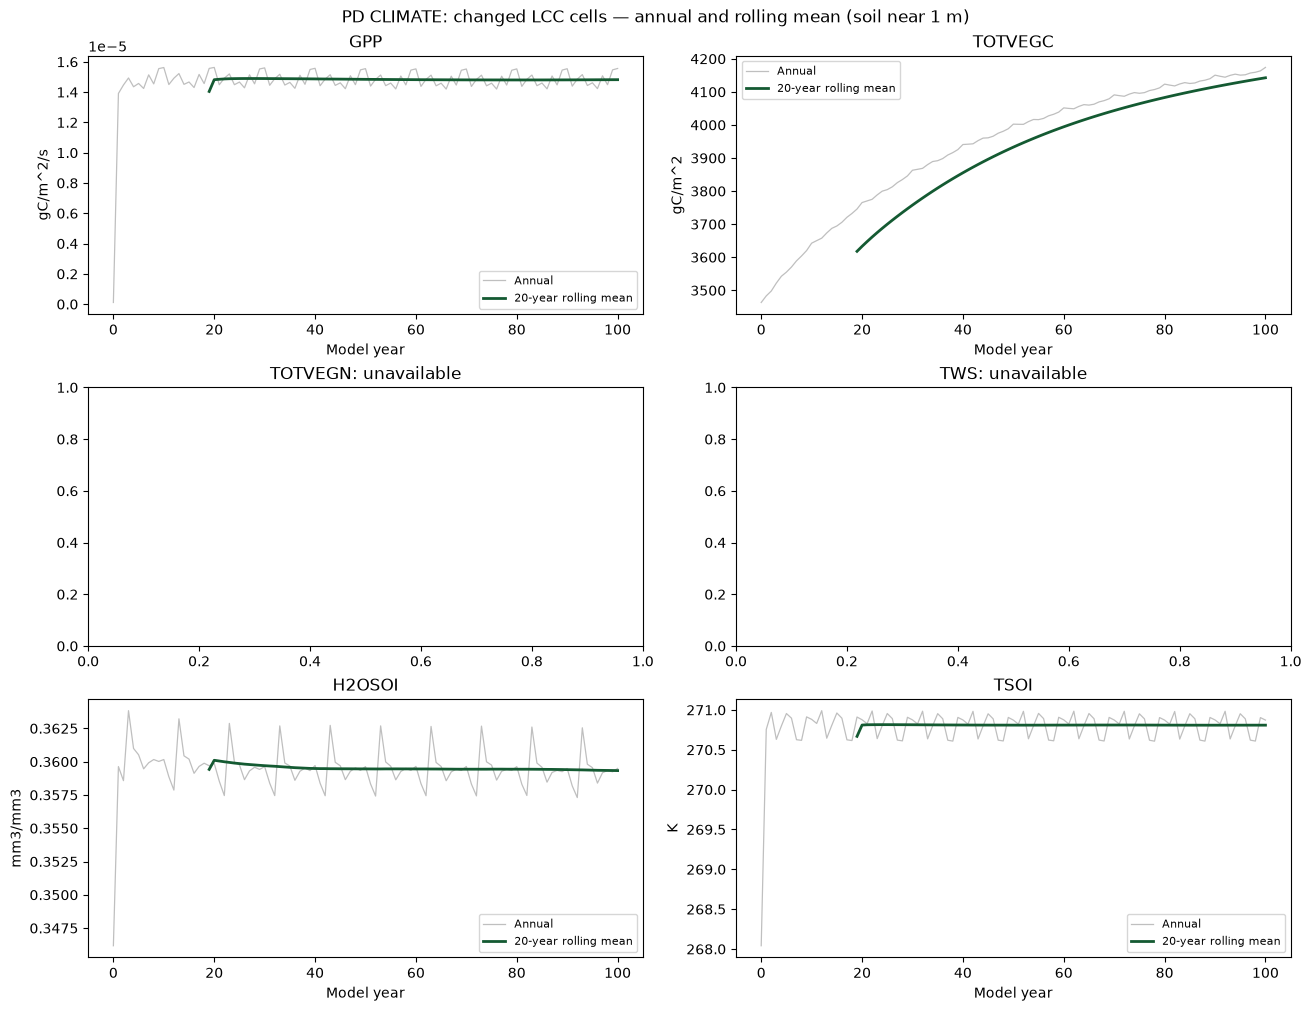

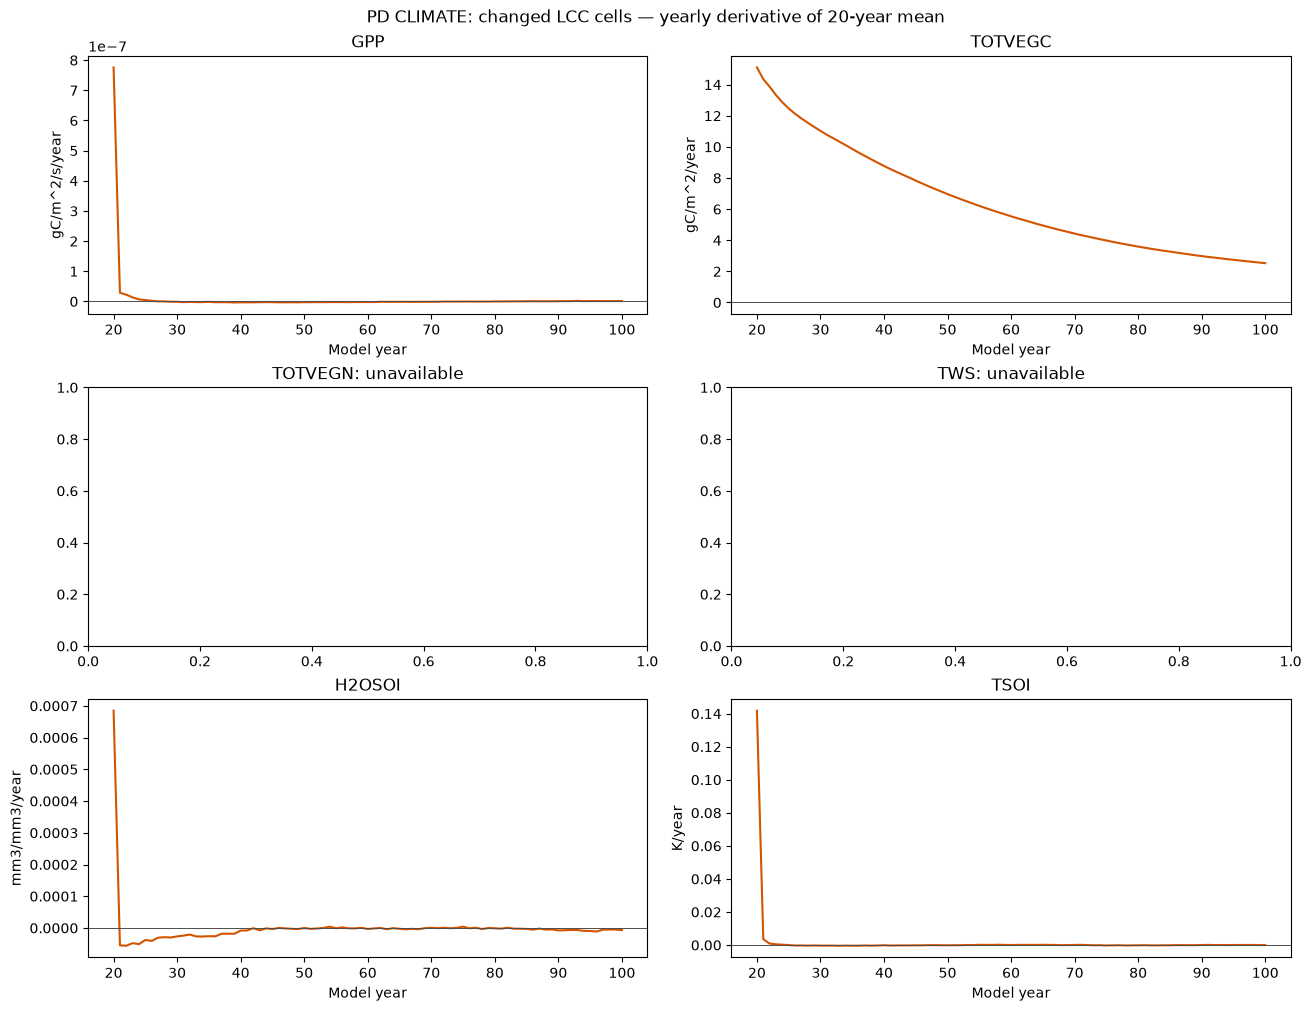

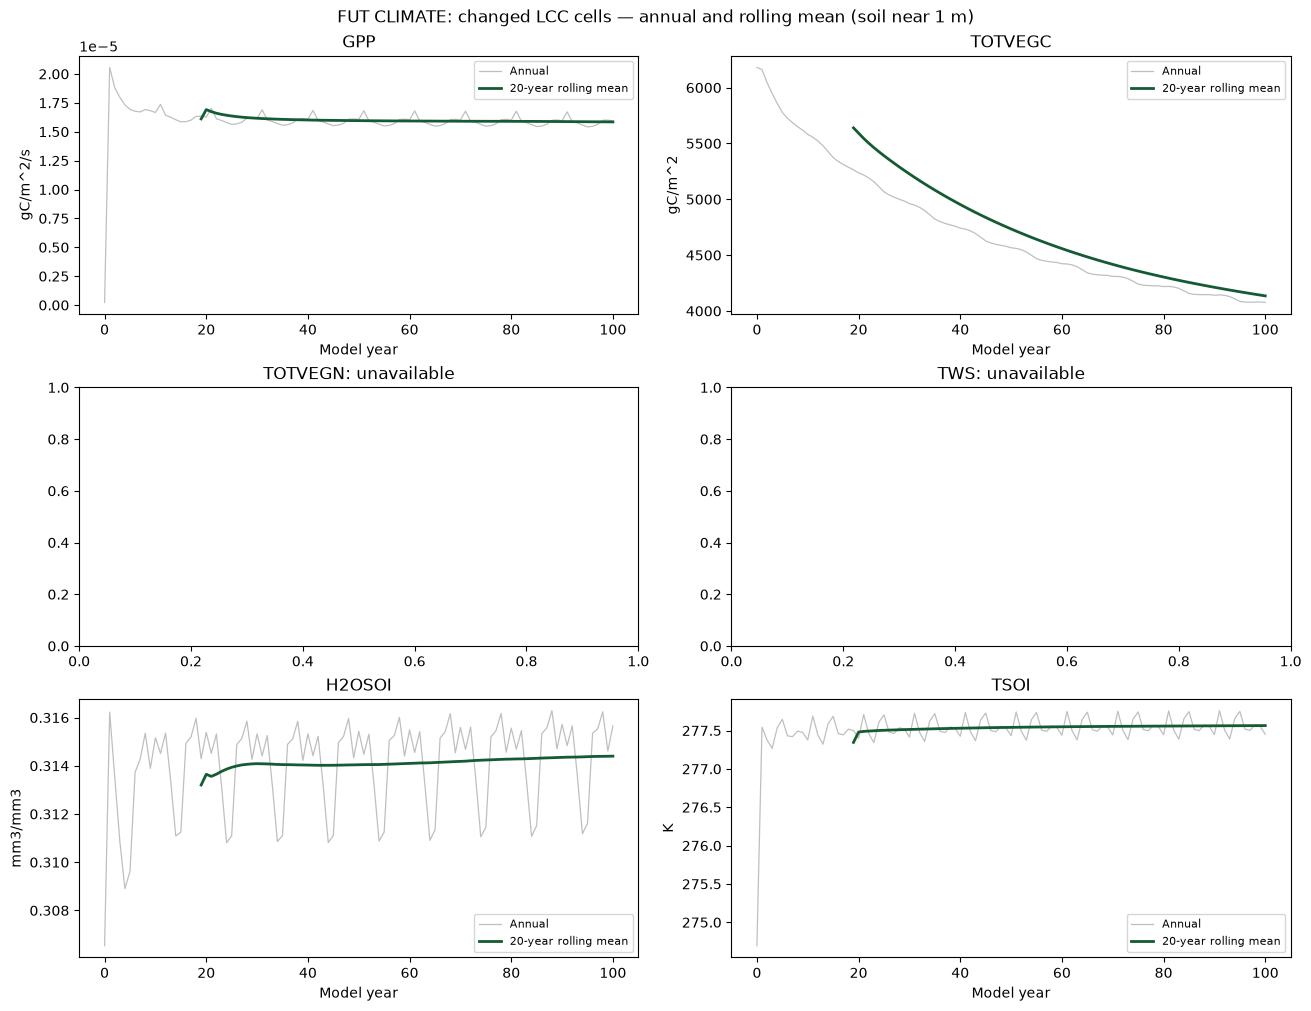

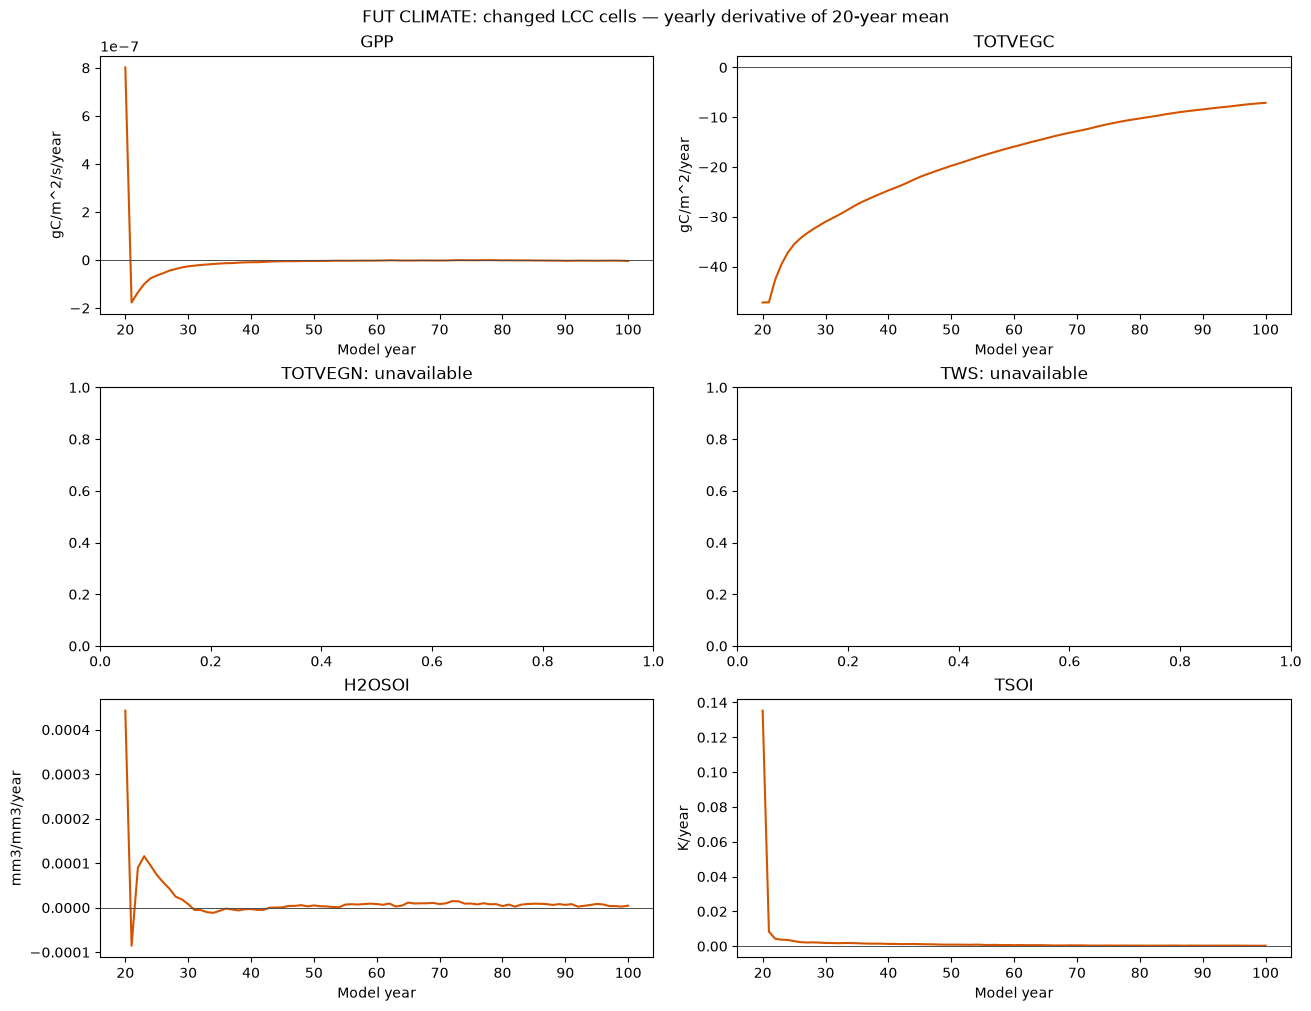

In [7]:
for name, item in DATA.items():
    for region, frame in item['table'].groupby('region'):
        fig, axes = plt.subplots(3, 2, figsize=(13, 10), layout='constrained')
        for ax, var in zip(axes.flat, CORE_VARIABLES):
            if var not in frame or frame[var].isna().all():
                ax.set(title=f'{var}: unavailable')
                continue
            result = rolling_diagnostics(frame, var)
            if result.empty:
                ax.set(title=f'{var}: need ≥21 consecutive years')
                continue
            ax.plot(result.index, result.annual, color='0.75', lw=0.9, label='Annual')
            ax.plot(result.index, result.rolling_mean, color='#145A32', lw=2,
                    label=f'{ROLL_YEARS}-year rolling mean')
            ax.set(title=var, xlabel='Model year',
                   ylabel=item['units'].get(var, 'unknown'))
            ax.legend(fontsize=8)
        fig.suptitle(f'{name}: {region} — annual and rolling mean (soil near 1 m)')
        plt.show()

        fig, axes = plt.subplots(3, 2, figsize=(13, 10), layout='constrained')
        for ax, var in zip(axes.flat, CORE_VARIABLES):
            if var not in frame or frame[var].isna().all():
                ax.set(title=f'{var}: unavailable')
                continue
            result = rolling_diagnostics(frame, var)
            if result.empty:
                ax.set(title=f'{var}: need ≥21 consecutive years')
                continue
            ax.plot(result.index, result.derivative, color='#D35400', lw=1.5)
            ax.axhline(0, color='0.3', lw=0.7)
            ax.set(title=var, xlabel='Model year',
                   ylabel=item['units'].get(var, 'unknown') + '/year')
        fig.suptitle(f'{name}: {region} — yearly derivative of {ROLL_YEARS}-year mean')
        plt.show()

## Time series and local change

The maps subtract the preceding 10-year mean from the final 10-year mean in the grid cells whose PFT composition changed. A small mean over those cells can still hide opposing local changes.

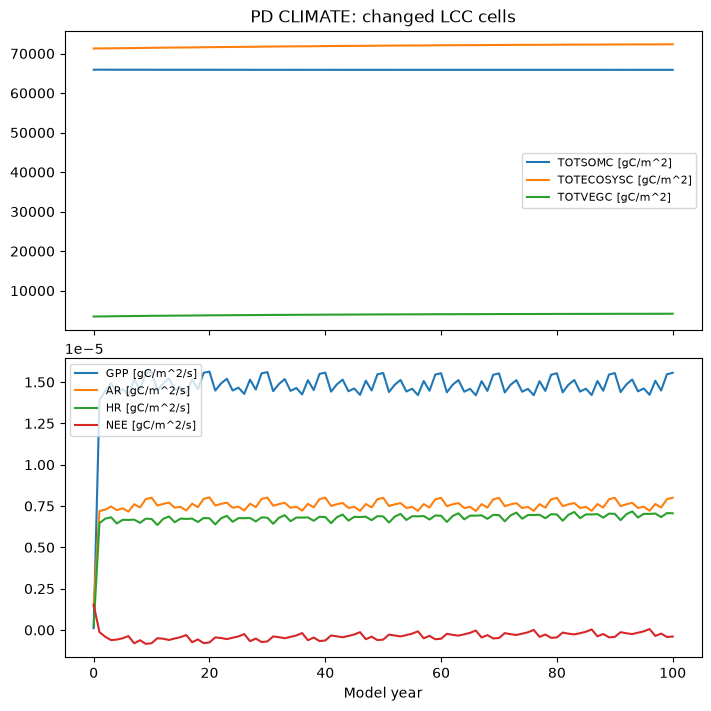

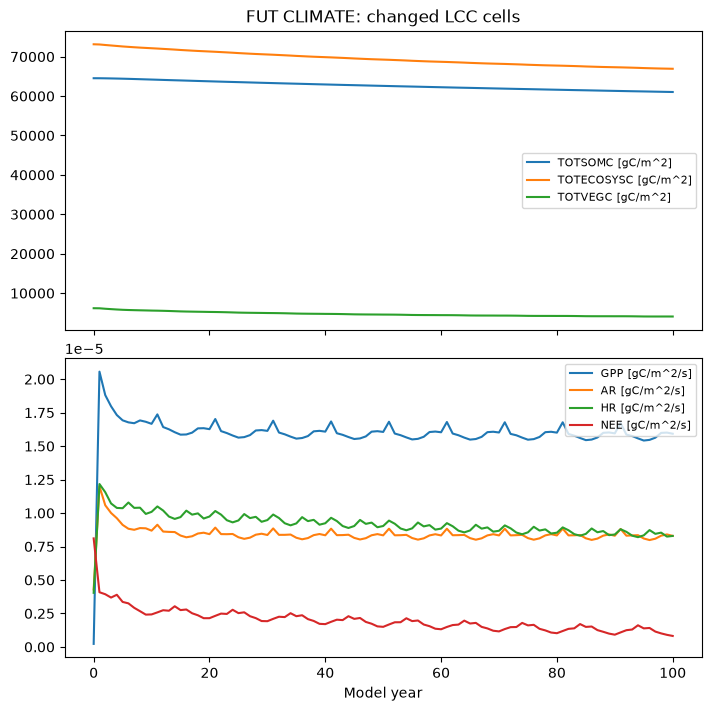

In [8]:
for name, item in DATA.items():
    table = item["table"]
    fig, axes = plt.subplots(2, 1, figsize=(7, 7), layout="constrained", sharex=True)

    for region, frame in table.groupby("region"):
        for ax, variables in zip(
            axes,
            (("TOTSOMC", "TOTECOSYSC", "TOTVEGC"), ("GPP", "AR", "HR", "NEE")),
        ):
            for var in variables:
                if var in frame:
                    ax.plot(frame.year, frame[var], label=f'{var} [{item["units"].get(var, "?")}]')
            ax.legend(fontsize=8)

        axes[0].set_title(f"{name}: {region}")
        axes[1].set_xlabel("Model year")

    plt.show()

In [9]:
"""def grid_mean(files, years, var):
    fields = []
    for file in files:
        with xr.open_dataset(file, decode_times=True) as ds:
            if var in ds:
                for i, year in enumerate(years_in(ds)):
                    if year in years:
                        fields.append(ds[var].isel(time=i).load())
    if len(fields) != len(years):
        raise ValueError(f'{var}: expected {len(years)} annual maps; found {len(fields)}')
    return xr.concat(fields, dim='sample').mean('sample')

import cartopy.crs as ccrs
from matplotlib.path import Path

theta = np.linspace(0, 2 * np.pi, 361)
circle = Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for name, item in DATA.items():
    blocks = full_blocks(item["table"].query('region == "changed LCC cells"'))
    if len(blocks) < 2:
        print(f"{name}: need two complete 10-year blocks for maps.")
        continue

    old, new = [set(block.year) for block in blocks[-2:]]
    for var in ("TOTSOMC", "TOTECOSYSC", "TOTVEGC"):
        if var not in item["units"]:
            continue

        change = grid_mean(item["files"], new, var) - grid_mean(item["files"], old, var)
        if set(change.dims) != {"lat", "lon"}:
            print(f"{var}: expected a 2D lat–lon field; got {change.dims}")
            continue

        mask = xr.DataArray(CHANGED_CELLS, dims=change.dims, coords=change.coords)
        change = change.where(mask)
        change = change.assign_coords(lon=((change.lon + 180) % 360) - 180).sortby("lon")

        values = np.abs(change.values)
        values = values[np.isfinite(values)]
        if not len(values):
            print(f"{name}, {var}: no valid values in changed cells")
            continue
        limit = max(float(np.percentile(values, 98)), 1e-12)

        fig, ax = plt.subplots(
            figsize=(5, 5),
            subplot_kw={"projection": ccrs.Orthographic(0, 90)},
            layout="constrained",
        )
        ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)

        mesh = change.plot.pcolormesh(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=-limit,
            vmax=limit,
            add_colorbar=False,
            infer_intervals=True,
        )
        ax.coastlines(resolution="110m", linewidth=0.6)
        ax.gridlines(linewidth=0.4, alpha=0.4)

        fig.colorbar(
            mesh, ax=ax, orientation="horizontal", shrink=0.8, pad=0.05,
            label=f"{var} change [{item['units'][var]}]",
        )
        ax.set_title(
            f"{name}: {var}\n"
            f"{min(new)}–{max(new)} minus {min(old)}–{max(old)}"
        )
        plt.show()"""

'def grid_mean(files, years, var):\n    fields = []\n    for file in files:\n        with xr.open_dataset(file, decode_times=True) as ds:\n            if var in ds:\n                for i, year in enumerate(years_in(ds)):\n                    if year in years:\n                        fields.append(ds[var].isel(time=i).load())\n    if len(fields) != len(years):\n        raise ValueError(f\'{var}: expected {len(years)} annual maps; found {len(fields)}\')\n    return xr.concat(fields, dim=\'sample\').mean(\'sample\')\n\nimport cartopy.crs as ccrs\nfrom matplotlib.path import Path\n\ntheta = np.linspace(0, 2 * np.pi, 361)\ncircle = Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)\n\nfor name, item in DATA.items():\n    blocks = full_blocks(item["table"].query(\'region == "changed LCC cells"\'))\n    if len(blocks) < 2:\n        print(f"{name}: need two complete 10-year blocks for maps.")\n        continue\n\n    old, new = [set(block.year) for block in blocks[-2:]]\n    f

## Check variables in the CTRL_PD run

Control months: 119, 2000-02 to 2009-12
Soil depths: {'H2OSOI': 1.06, 'TSOI': 1.06}
Missing variables: []


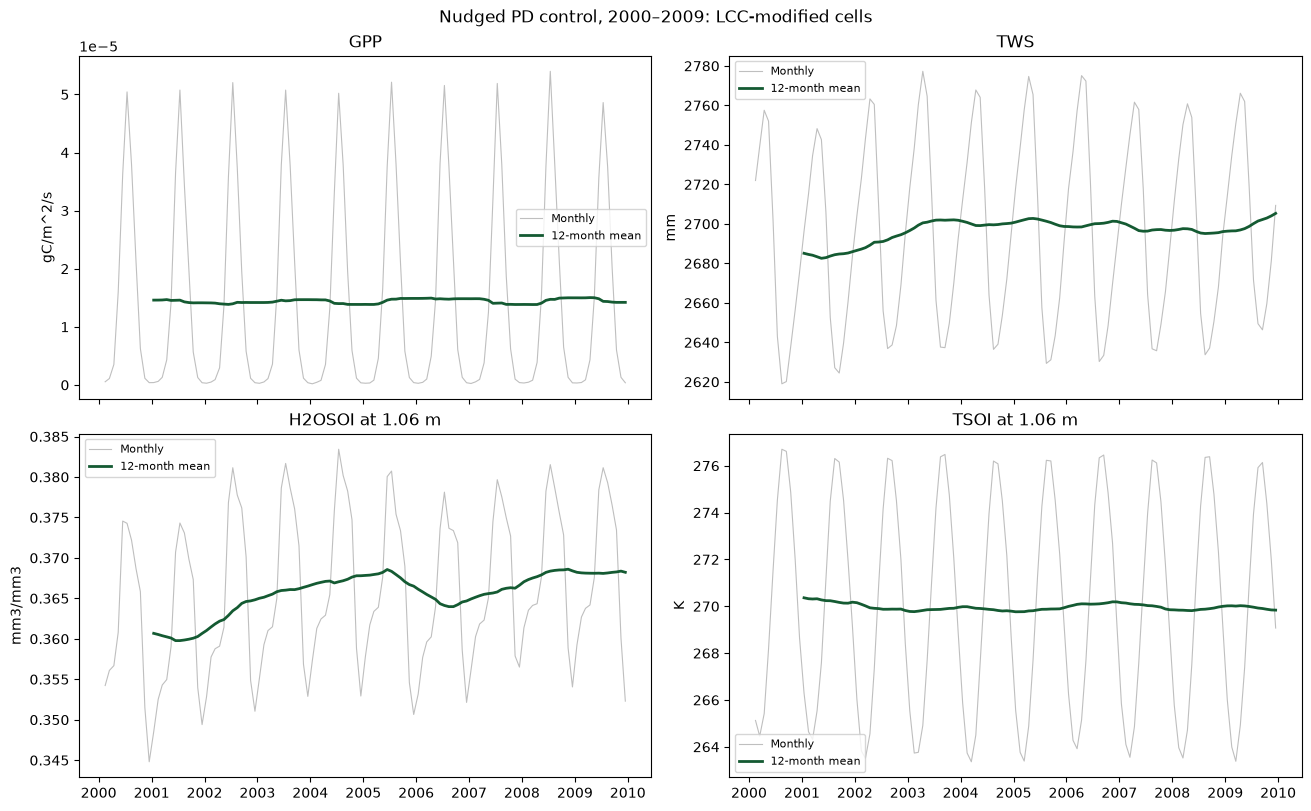

In [10]:
from pathlib import Path as FilePath
from datetime import timedelta

CTRL_HIST = FilePath('/cluster/home/adelez/nird/BRL-FRST-XPSN_archive/NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-20260429/lnd/hist')
CTRL_VARS = ("GPP", "TWS", "H2OSOI", "TSOI")
ctrl_files = sorted(CTRL_HIST.glob("*.clm2.h0.*.nc"))
if not ctrl_files:
    raise FileNotFoundError(f"No CLM h0 files in {CTRL_HIST}")

def at_soil_depth(ds, field):
    vertical = next((d for d in ("levsoi", "levgrnd") if d in field.dims), None)
    if vertical is None:
        raise ValueError(f"{field.name} has no soil-level dimension")

    depth_var = vertical if vertical in ds.variables else "levgrnd"
    depths = np.asarray(ds[depth_var].values[:field.sizes[vertical]], dtype=float)
    if ds[depth_var].attrs.get("units", "m").lower() in ("cm", "centimeters"):
        depths /= 100

    index = int(np.argmin(abs(depths - SOIL_DEPTH_M)))
    return field.isel({vertical: index}), float(depths[index])

records, ctrl_units, selected_depths = [], {}, {}
for file in ctrl_files:
    with xr.open_dataset(file, decode_times=True) as ds:
        weights = weights_in(ds)
        weights = weights.where(changed_mask_for(ds, weights), 0)
        bounds = next((v for v in ("time_bounds", "time_bnds") if v in ds), None)
        dates = (
            ds[bounds].isel({ds[bounds].dims[-1]: 0}).values
            if bounds else ds.time.values
        )

        for i, date in enumerate(dates):
            if isinstance(date, np.datetime64):
                date = pd.Timestamp(date)
            if bounds is None and date.day == 1:
                date -= timedelta(days=1)  # Monthly means may be stamped next month.
            if not 2000 <= date.year <= 2009:
                continue

            row = {"date": pd.Timestamp(date.year, date.month, 15)}
            for var in CTRL_VARS:
                if var not in ds:
                    continue
                field = ds[var].isel(time=i)
                if var in SOIL_VARIABLES:
                    field, depth = at_soil_depth(ds, field)
                    selected_depths[var] = depth
                field = field.squeeze(drop=True)

                valid = weights.where(np.isfinite(field), 0)
                total = float(valid.sum())
                row[var] = float((field.fillna(0) * valid).sum() / total) if total else np.nan
                ctrl_units[var] = ds[var].attrs.get("units", "unknown")
            records.append(row)

ctrl_monthly = pd.DataFrame(records).sort_values("date").set_index("date")
if ctrl_monthly.index.has_duplicates:
    raise ValueError("Duplicate months found in control history files")

print(f"Control months: {len(ctrl_monthly)}, {ctrl_monthly.index.min():%Y-%m} to "
      f"{ctrl_monthly.index.max():%Y-%m}")
print("Soil depths:", selected_depths)
print("Missing variables:", [v for v in CTRL_VARS if v not in ctrl_monthly])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained", sharex=True)
for ax, var in zip(axes.flat, CTRL_VARS):
    if var not in ctrl_monthly:
        ax.set_title(f"{var}: unavailable")
        continue

    series = ctrl_monthly[var]
    smooth = series.rolling(12, min_periods=12).mean()
    ax.plot(series.index, series, color="0.75", lw=0.8, label="Monthly")
    ax.plot(smooth.index, smooth, color="#145A32", lw=2, label="12-month mean")
    depth_label = f" at {selected_depths[var]:.2f} m" if var in selected_depths else ""
    ax.set(title=var + depth_label, ylabel=ctrl_units[var])
    ax.legend(fontsize=8)

fig.suptitle("Nudged PD control, 2000–2009: LCC-modified cells")
plt.show()

## Check variables in the FUT_SPINUP run

H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m
TSOI: selecting level 8, depth 1.060 m
H2OSOI: selecting level 8, depth 1.060 m

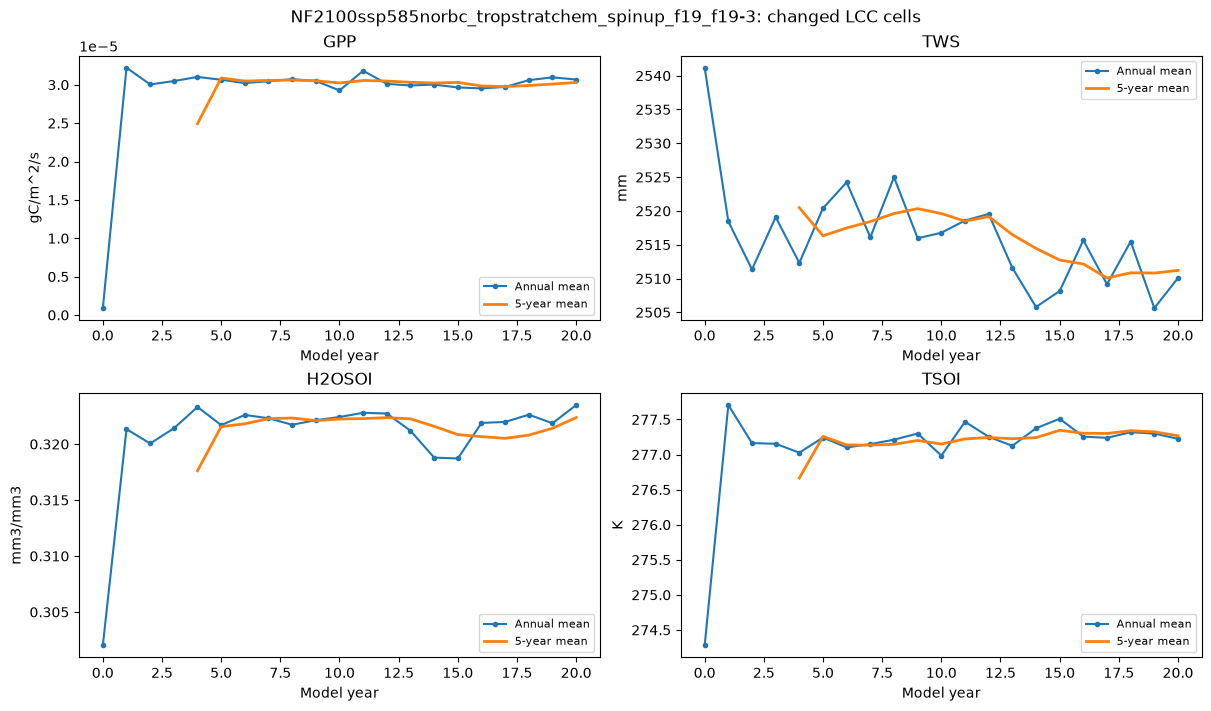

In [12]:
from pathlib import Path as FilePath  # avoids the matplotlib.path.Path name collision

FUT_CASE = "NF2100ssp585norbc_tropstratchem_spinup_f19_f19-3"
FUT_HIST = FilePath(
    f"/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN_archive/"
    f"{FUT_CASE}/lnd/hist"
)
FUT_VARS = ("GPP", "TWS", "H2OSOI", "TSOI")
SOIL_DIMS = {"H2OSOI": "levsoi", "TSOI": "levgrnd"}

files = sorted(FUT_HIST.glob("*.clm2.h0.*.nc"))
if not files:
    raise FileNotFoundError(f"No CLM h0 files in {FUT_HIST}")

rows = []
missing = set(FUT_VARS)

for file in files:
    with xr.open_dataset(file, decode_times=True) as ds:
        weights = weights_in(ds)
        mask = changed_mask_for(ds, weights)
        spatial_dims = weights.dims
        masked_weights = weights.where(mask, 0).fillna(0)

        # CLM monthly timestamps can fall on the first day of the next month.
        # Use the beginning of each time interval to label its actual month.
        bounds_name = next(
            (key for key in ("time_bounds", "time_bnds") if key in ds), None
        )
        if bounds_name is None:
            raise ValueError(f"{file}: no time bounds; inspect month labels")
        bound_dim = next(dim for dim in ds[bounds_name].dims if dim != "time")
        starts = ds[bounds_name].isel({bound_dim: 0}).values

        for var in FUT_VARS:
            if var not in ds:
                continue
            missing.discard(var)
            field = ds[var]



            if var in SOIL_DIMS:
                depth_dim = next((d for d in ("levsoi", "levgrnd") if d in field.dims), None)
                if depth_dim is None:
                    raise ValueError(f"{file}: {var} has no recognised soil dimension: {field.dims}")
            
                nlevels = field.sizes[depth_dim]
                if "levgrnd" in ds and ds.levgrnd.ndim == 1 and ds.levgrnd.size >= nlevels:
                    depths = np.asarray(ds.levgrnd.values[:nlevels], dtype=float)
                    level = int(np.abs(depths - 1.0).argmin())
                    #print(f"{var}: selecting level {level}, depth {depths[level]:.3f} m")
                else:
                    raise ValueError(
                        f"{file}: cannot establish the depth of {var}; "
                        "show the inspection output before selecting a level by index"
                    )
            
                field = field.isel({depth_dim: level})

            extra = set(field.dims) - {"time", *spatial_dims}
            if extra:
                raise ValueError(f"{file}: {var} has unexpected dimensions {extra}")

            mean = field.weighted(masked_weights).mean(spatial_dims)
            for stamp, value in zip(starts, mean.values):
                rows.append({
                    "variable": var,
                    "year": int(stamp.year),
                    "month": int(stamp.month),
                    "value": float(value),
                    "units": ds[var].attrs.get("units", ""),
                })

fut_monthly = pd.DataFrame(rows)
for var in sorted(missing):
    print(f"{var}: absent from these h0 files; check other history streams.")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained")
for ax, var in zip(axes.flat, FUT_VARS):
    series = fut_monthly[fut_monthly.variable == var]
    if series.empty:
        ax.text(0.5, 0.5, "Not in h0 output", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(var)
        continue

    annual = series.groupby("year").value.mean().sort_index()
    ax.plot(annual.index, annual, marker=".", label="Annual mean")
    ax.plot(annual.index, annual.rolling(5, min_periods=5).mean(),
            linewidth=2, label="5-year mean")
    ax.set(title=var, xlabel="Model year",
           ylabel=series.units.iloc[0] or "See file units")
    ax.legend(fontsize=8)

fig.suptitle(f"{FUT_CASE}: changed LCC cells")
plt.show()

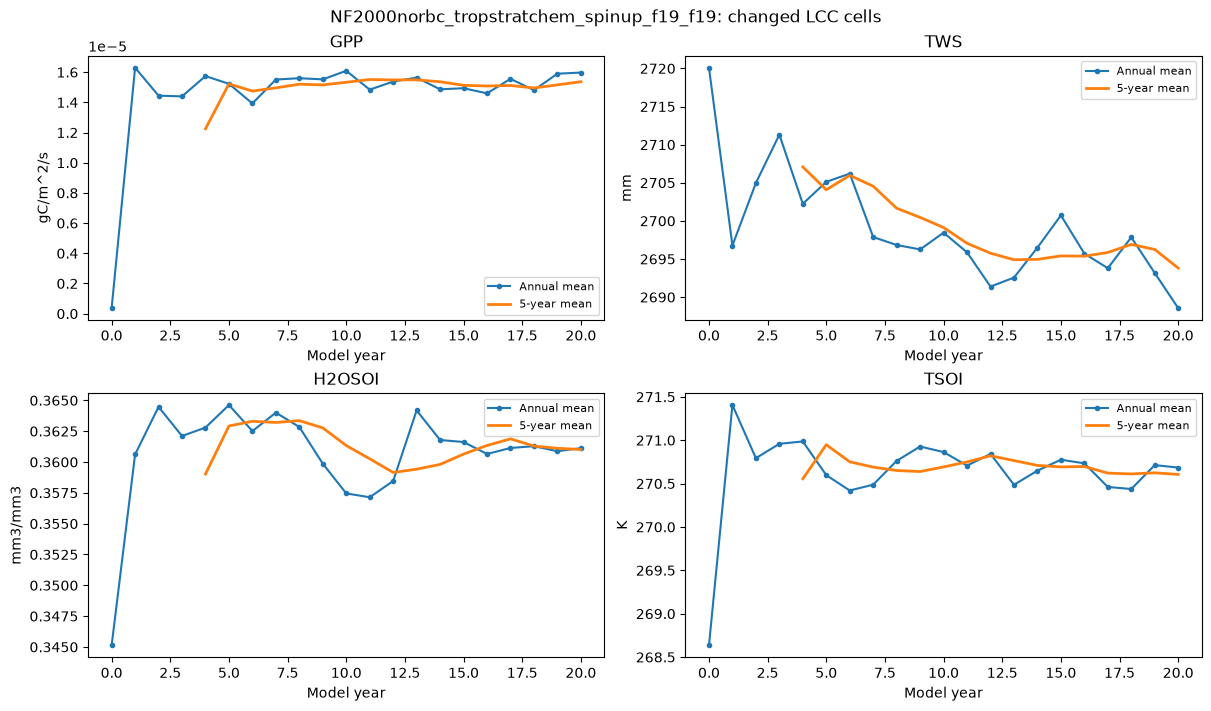

In [14]:

PD_CASE = "NF2000norbc_tropstratchem_spinup_f19_f19"
PD_HIST = FilePath(
    f"/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN_archive/"
    f"{PD_CASE}/lnd/hist"
)
PD_VARS = ("GPP", "TWS", "H2OSOI", "TSOI")
SOIL_DIMS = {"H2OSOI": "levsoi", "TSOI": "levgrnd"}

files = sorted(PD_HIST.glob("*.clm2.h0.*.nc"))
if not files:
    raise FileNotFoundError(f"No CLM h0 files in {PD_HIST}")

rows = []
missing = set(PD_VARS)

for file in files:
    with xr.open_dataset(file, decode_times=True) as ds:
        weights = weights_in(ds)
        mask = changed_mask_for(ds, weights)
        spatial_dims = weights.dims
        masked_weights = weights.where(mask, 0).fillna(0)

        # CLM monthly timestamps can fall on the first day of the next month.
        # Use the beginning of each time interval to label its actual month.
        bounds_name = next(
            (key for key in ("time_bounds", "time_bnds") if key in ds), None
        )
        if bounds_name is None:
            raise ValueError(f"{file}: no time bounds; inspect month labels")
        bound_dim = next(dim for dim in ds[bounds_name].dims if dim != "time")
        starts = ds[bounds_name].isel({bound_dim: 0}).values

        for var in PD_VARS:
            if var not in ds:
                continue
            missing.discard(var)
            field = ds[var]



            if var in SOIL_DIMS:
                depth_dim = next((d for d in ("levsoi", "levgrnd") if d in field.dims), None)
                if depth_dim is None:
                    raise ValueError(f"{file}: {var} has no recognised soil dimension: {field.dims}")
            
                nlevels = field.sizes[depth_dim]
                if "levgrnd" in ds and ds.levgrnd.ndim == 1 and ds.levgrnd.size >= nlevels:
                    depths = np.asarray(ds.levgrnd.values[:nlevels], dtype=float)
                    level = int(np.abs(depths - 1.0).argmin())
                    #print(f"{var}: selecting level {level}, depth {depths[level]:.3f} m")
                else:
                    raise ValueError(
                        f"{file}: cannot establish the depth of {var}; "
                        "show the inspection output before selecting a level by index"
                    )
            
                field = field.isel({depth_dim: level})

            extra = set(field.dims) - {"time", *spatial_dims}
            if extra:
                raise ValueError(f"{file}: {var} has unexpected dimensions {extra}")

            mean = field.weighted(masked_weights).mean(spatial_dims)
            for stamp, value in zip(starts, mean.values):
                rows.append({
                    "variable": var,
                    "year": int(stamp.year),
                    "month": int(stamp.month),
                    "value": float(value),
                    "units": ds[var].attrs.get("units", ""),
                })

pd_monthly = pd.DataFrame(rows)
for var in sorted(missing):
    print(f"{var}: absent from these h0 files; check other history streams.")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained")
for ax, var in zip(axes.flat, PD_VARS):
    series = pd_monthly[pd_monthly.variable == var]
    if series.empty:
        ax.text(0.5, 0.5, "Not in h0 output", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(var)
        continue

    annual = series.groupby("year").value.mean().sort_index()
    ax.plot(annual.index, annual, marker=".", label="Annual mean")
    ax.plot(annual.index, annual.rolling(5, min_periods=5).mean(),
            linewidth=2, label="5-year mean")
    ax.set(title=var, xlabel="Model year",
           ylabel=series.units.iloc[0] or "See file units")
    ax.legend(fontsize=8)

fig.suptitle(f"{PD_CASE}: changed LCC cells")
plt.show()

### Adjustment in cells with changed land cover

Across the 1,161 cells whose natural PFT fractions changed, soil temperature and volumetric soil water at the model level nearest 1 m (1.06 m) show small changes late in both 100-year land runs. Their 20-year rolling means are nearly flat late in the runs.
These spatial means suggest that the sampled soil layer has adjusted substantially.

Vegetation carbon is still drifting, especially in the future run. But it is not the focus of this euqilibrium check.

TOTVEGN and TWS are absent from these h0 files. It is not possible to reconstruct past missing fields. Optionally, missing diagnostics can  be added to CLM history output and rerun.